### Sources:
    Mass:
    https://www.cdc.gov/nchs/fastats/body-measurements.htm 
    https://www.amazon.com/Flybar-Super-Adults-Weights-120-210/dp/B00005B60A

    Spring Constant:
    Because the spring constant is usually private and not stated by companies, we will use an estimate provided by Gemini Pro 3.1 based on weights the Spring: "The Super Pogo is specifically engineered with a heavy-duty metal coil designed to support riders weighing between 120 and 210 pounds (roughly 54 kg to 95 kg)...Based on the physics required to support that weight range during active bouncing, the Super Pogo's spring constant is estimated to be between 15,000 N/m and 25,000 N/m (roughly 85 to 143 lb/in)." I will choose the maximum constant in order to demonstrate more critical constants.

    Dampening Constant:
        https://www.scribd.com/document/442564794/P-639-pdf#content=query:mass,pageNum:10,indexOnPage:0,bestMatch:false

    Initial Displacement:
    https://pubs.aip.org/aapt/pte/article/49/L1/L2/275250/Pogo-stick-spring



### Part 1 and 2:
    For the Final Project in Part 1 I will be researching the Spring-Mass System ODE on a pogo stick. This equation allows to calculate the change in distance over time of the spring when there is mass, damping, and springs involved. It will not calculate how far high the person or object goes, but rather how much the spring is displaced. The governing equation the second order ODE of a mass-spring system. I will convert them into first-order ODE through forward Euler and RK4. I will first start by stating the parameters (they will be in metric units in order to be consistent):

    Equations:
    m(d^2y/dt^2) + c(dy/dt) + ky = 0


    Mass = 72.7 kg + 4 kg = 76.7 kg
    (I took the average mass of a human male teen since it was provided by CDC and pogo sticks are usually toys for children/teenagers + the average mass of a steel frame "Super Pogo" by Flybar pogo stick)

    Spring Constant = 25000 N/m

    Dampening Constant = 250 N*s/m
    We will use the damping centered on a rubber stopper against concrete, which gives a damping coefficient of 250 N*s/m

    Initial Displacement : Because a pogo stick must have some initial compression, the data cannot extrapolate to (0,0), so it will have initial displacement of 0.02 at t = 0, and it will be at the moment when it just hits the ground.



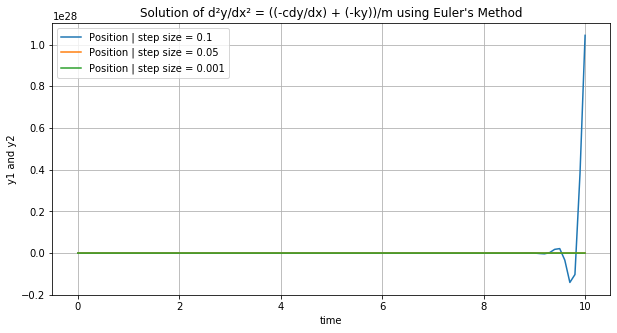

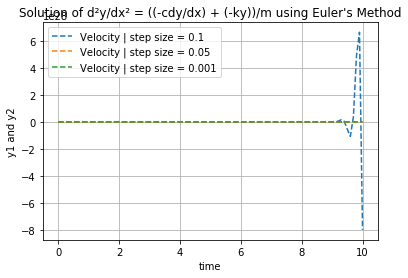

Hello World!


In [6]:
#Part 3:
import numpy as np
import matplotlib.pyplot as plt

#Parameters:
#d^2y/dt^2 = f(t, y, dy/dt)
#dy1/dt = y2
#dy2/dt = f(t, y1, y2)

# Define the parameters
m = 76.7
k = 25000        # Constant in the equation (e.g., spring constant)
stepSizes = [0.1, 0.05, 0.001]       # Step size
c = 250        # Dampiing constant
t_start = 0    # Start of the interval
t_end = 10     # End of the interval
y1_0 = 0.02      # Initial condition for y
y2_0 = 0.0      # Initial condition for dy/dx

def euler_method_SpringMass(m, h, k, c, t_start, t_end, y1_0, y2_0):
    # Create arrays to store t, y1, and y2 values
    t_values = np.arange(t_start, t_end + h, h)
    y1_values = np.zeros(len(t_values))
    y2_values = np.zeros(len(t_values))

    # Set initial conditions
    y1_values[0] = y1_0
    y2_values[0] = y2_0
    
    # Euler's Method loop
    for i in range(1, len(t_values)):
        # Current values
        y1_n = y1_values[i - 1]
        y2_n = y2_values[i - 1]    

        # Update equations
        y2_values[i] = y2_n + h * (((-c*y2_n) + (-k * y1_n))/m)
        y1_values[i] = y1_n + h * y2_n
        
    return t_values, y1_values, y2_values
        
plt.figure(figsize = (10,5))
           
for h in stepSizes:
    t, y1, y2 = euler_method_SpringMass(m, h, k, c, t_start, t_end, y1_0, y2_0)
    plt.plot(t, y1, label= f'Position | step size = {h}')
    
# Plot the results
plt.xlabel('time')
plt.ylabel('y1 and y2')
plt.title('Solution of d²y/dx² = ((-cdy/dx) + (-ky))/m using Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()

    
for h in stepSizes:
    t, y1, y2 = euler_method_SpringMass(m, h, k, c, t_start, t_end, y1_0, y2_0)
    plt.plot(t, y2, label= f'Velocity | step size = {h}', linestyle = '--')  
    
# Plot the results
plt.xlabel('time')
plt.ylabel('y1 and y2')
plt.title('Solution of d²y/dx² = ((-cdy/dx) + (-ky))/m using Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()

print("Hello World!") #TF2 coconut



I was really confused on how to use runge kutta with a 2nd order ODE, so I asked Gemini Pro 3.1 by prompting a copy paste of my current code and asking "I am trying to do the runge_kutta for the previous, but I am confused on how to write it out"

I will have an appendix with full prompts.

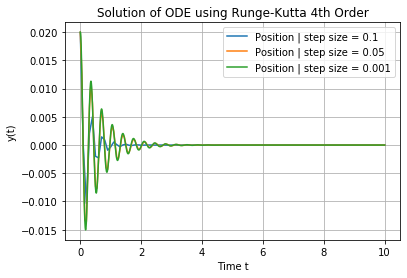

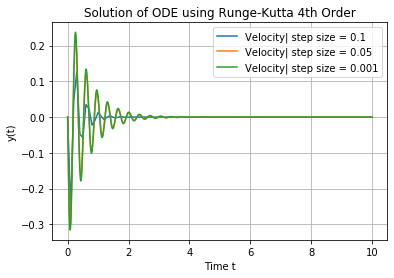

In [3]:
#Part 3 Cont.:
#For each time step, calculate four slopes (k1, k2, k3, k4)
#and combine them with weights: (k1 + 2k2 + 2k3 + k4)/6

# Define the ODE function, for example, dy/dt = f(t, y) = -2 *t * y^2
def f(t, y1, y2, m, c, k):
    dy1_dt = y2
    dy2_dt = (((-c*y2) + (-k * y1))/m)
    return dy1_dt, dy2_dt

# Implement the RK4 method
def runge_kutta_4(f, y1_0, y2_0, t0, tf, h):
    # Create an array for time steps
    t_values = np.arange(t0, tf + h, h)
    y1_values = np.zeros(len(t_values))
    y2_values = np.zeros(len(t_values))
    
    # Set the initial condition 
    y1_values[0] = y1_0
    y2_values[0] = y2_0
    # Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y1 = y1_values[i - 1]
        y2 = y2_values[i - 1]
        
        k1_y1, k1_y2 = f(t, y1, y2, m, c, k)
        k2_y1, k2_y2 = f(t + h / 2, y1 + (h/2 * k1_y1), y2 + (h/2 * k1_y2), m, c, k)
        k3_y1, k3_y2 = f(t + h / 2, y1 + (h/2 * k2_y1), y2 + (h/2 * k2_y2), m, c, k)
        k4_y1, k4_y2 = f(t + h, y1 + (h * k3_y1), y2 + (h * k3_y2), m, c, k)
                         
    # Update y based on the RK4 formula
        y1_values[i] = y1 + (h / 6) * (k1_y1 + 2*k2_y1 + 2*k3_y1 + k4_y1)
        y2_values[i] = y2 + (h / 6) * (k1_y2 + 2*k2_y2 + 2*k3_y2 + k4_y2)
    return t_values, y1_values, y2_values

# Run the RK4 solver
for h in stepSizes:
    t_values, y1_values, y2_values = runge_kutta_4(f, y1_0, y2_0, t_start, t_end, h)
    plt.plot(t_values, y1_values, label= f'Position | step size = {h}')

plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Solution of ODE using Runge-Kutta 4th Order')
plt.legend()
plt.grid(True)
plt.show()   

for h in stepSizes:
    t_values, y1_values, y2_values = runge_kutta_4(f, y1_0, y2_0, t_start, t_end, h)
    plt.plot(t_values, y2_values, label= f'Velocity| step size = {h}')

# Plot the results
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Solution of ODE using Runge-Kutta 4th Order')
plt.legend()
plt.grid(True)
plt.show()

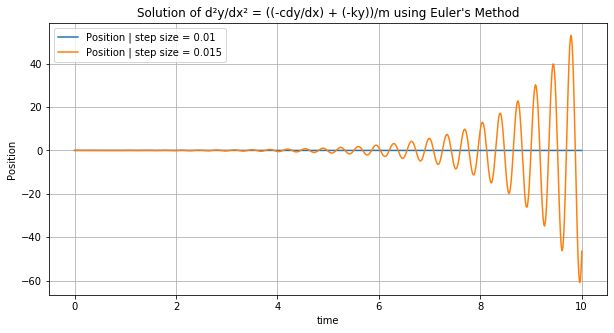

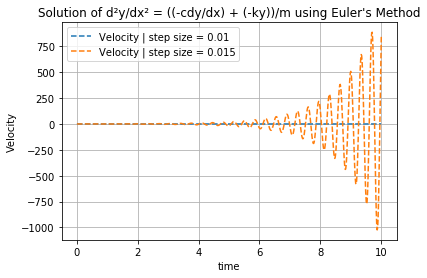

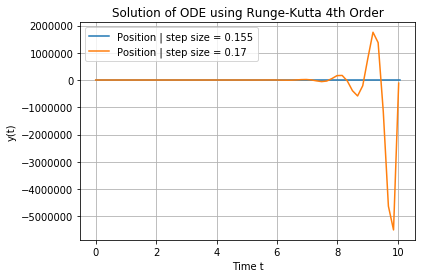

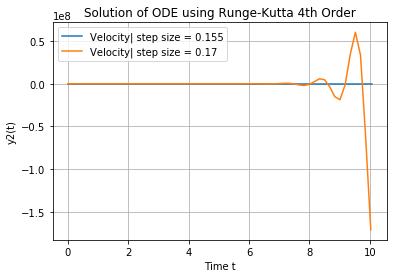

In [4]:
# Part 4a:

# Equation for natural frequency on Spring-Mass System:
# wn = sqrt(k/m)
# This gives estimated wn = 18.05 rad/s
# Forward Euler will be stable when h <= c/k which means h <= 0.01
# For RK4, it is stable if h <= 2.8/wn; I also got the value from Gemini 3.1 Pro
# So, for RK4, h <= 0.155

#Euler Forward
plt.figure(figsize = (10,5))
stepSizesEuler = [0.01, 0.015]          
for h in stepSizesEuler:
    t, y1, y2 = euler_method_SpringMass(m, h, k, c, t_start, t_end, y1_0, y2_0)
    plt.plot(t, y1, label= f'Position | step size = {h}')
    
# Plot the results
plt.xlabel('time')
plt.ylabel('Position')
plt.title('Solution of d²y/dx² = ((-cdy/dx) + (-ky))/m using Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()

    
for h in stepSizesEuler:
    t, y1, y2 = euler_method_SpringMass(m, h, k, c, t_start, t_end, y1_0, y2_0)
    plt.plot(t, y2, label= f'Velocity | step size = {h}', linestyle = '--')  
    
# Plot the results
plt.xlabel('time')
plt.ylabel('Velocity')
plt.title('Solution of d²y/dx² = ((-cdy/dx) + (-ky))/m using Euler\'s Method')
plt.legend()
plt.grid(True)
plt.show()


#RK4
stepSizesRK4 = [0.155, 0.17]  
# Run the RK4 solver
for h in stepSizesRK4:
    t_values, y1_values, y2_values = runge_kutta_4(f, y1_0, y2_0, t_start, t_end, h)
    plt.plot(t_values, y1_values, label= f'Position | step size = {h}')

plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Solution of ODE using Runge-Kutta 4th Order')
plt.legend()
plt.grid(True)
plt.show()   

for h in stepSizesRK4:
    t_values, y1_values, y2_values = runge_kutta_4(f, y1_0, y2_0, t_start, t_end, h)
    plt.plot(t_values, y2_values, label= f'Velocity| step size = {h}')

# Plot the results
plt.xlabel('Time t')
plt.ylabel('y2(t)')
plt.title('Solution of ODE using Runge-Kutta 4th Order')
plt.legend()
plt.grid(True)
plt.show()

As soon, when the step size becomes too large, the function becomes too unstable. This is to the point that the outputs are different from the stable one by orders of magnitude, and they also grow instead of decay throughout time.

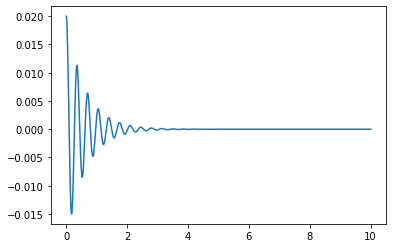

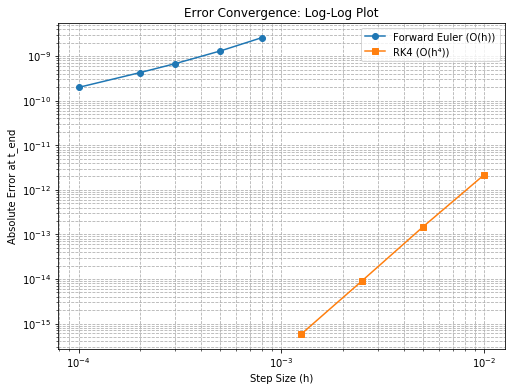

Euler Convergence Slope: 1.23
RK4 Convergence Slope: 3.97


In [5]:
#4.b:
#For finding the analytical solution, I prompted Gemini 3.1 Pro; Prompt 3

def analytical_sol(D, w, t, A, B, wdamp):
    return np.exp(-D*w*t)*(A*np.cos(wdamp*t) + B*np.sin(wdamp*t))

w = np.sqrt(k/m)    # w is the natural frequency
D = c/(2*np.sqrt(m*k))    # D is the damping coefficient
wdamp = w*np.sqrt(1 - D**2)    # wdamp is the "damped frequency"
A = y1_0    # A and B are values given by initial conditions
B = (y2_0 + D*w*y1_0)/wdamp

stepSizesEuler = [0.0008, 0.0005, 0.0003, 0.0002, 0.0001]
stepSizesRK4 = [0.01, 0.005, 0.0025, 0.00125]
euler_errors = []
RK4_errors = []

t_analytical = np.linspace(t_start, t_end, 1000) # Checking Analytical

plt.plot(t_analytical, analytical_sol(D, w, t_analytical, A, B, wdamp), label="Analytical Solution")

for h in stepSizesEuler:
    #Run Euler
    t_e, y1_e, y2_e = euler_method_SpringMass(m, h, k, c, t_start, t_end, y1_0, y2_0)
    y_analytical = analytical_sol(D, w, t_e[-1], A, B, wdamp)
    euler_errors.append(np.abs(y1_e[-1] - y_analytical))

for h in stepSizesRK4:
    #Run RK4
    t_rk, y1_rk, y2_rk = runge_kutta_4(f, y1_0, y2_0, t_start, t_end, h)
    y_analytical = analytical_sol(D, w, t_rk[-1], A, B, wdamp)
    RK4_errors.append(np.abs(y1_rk[-1] - y_analytical))
    
# 3. Create the Log-Log Plot
plt.figure(figsize=(8, 6))
plt.loglog(stepSizesEuler, euler_errors, '-o', label='Forward Euler (O(h))')
plt.loglog(stepSizesRK4, RK4_errors, '-s', label='RK4 (O(h⁴))')

plt.xlabel('Step Size (h)')
plt.ylabel('Absolute Error at t_end')
plt.title('Error Convergence: Log-Log Plot')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# 4. Verify Slopes (Convergence Rates)
euler_slope = np.polyfit(np.log(stepSizesEuler), np.log(euler_errors), 1)[0]
rk4_slope = np.polyfit(np.log(stepSizesRK4), np.log(RK4_errors), 1)[0]

print(f"Euler Convergence Slope: {euler_slope:.2f}") # Should be ~1
print(f"RK4 Convergence Slope: {rk4_slope:.2f}")     # Should be ~4

#### Part 4.c:
    The numerical instabilities did lead to non-physical result, such as increasing the peaks of the oscillations throughout time as opposed to them decaying. This means that the system grew as opposed to decaying from both the spring and dampening. When the RK4 was stable, the equation accurately demonstrated the decay of the position within the pogo stick. 

### Conclusion: 
    The preferable method would be the RK4 because it is more robust and can handle a higher step size. This means that it would not cost more computational power since the computer would not have to calculate more steps. Compared to the Euler's Forward Method, because it would require step sizes to the 0.01 range, which is computationally expensive. Overall RK4 would be more efficient. A lessoned learned would be to try to implement RK4 on higher orders than 1 since it can handle them. 

### Appendix A: Google Gemini 3.1 Pro prompts:
    ##First Prompt:

    """
    #For each time step, calculate four slopes (k1, k2, k3, k4)
    #and combine them with weights: (k1 + 2k2 + 2k3 + k4)/6

    #Define the ODE function, for example, dy/dt = f(t, y) = -2 *t * y^2
    def f(t, y1, y2, m, c, k):
        return y2_n + h * (((-c*y2) + (-k * y1))/m)

    #Implement the RK4 method
    def runge_kutta_4(f, y1_0, y2_0, t0, tf, h):
        # Create an array for time steps
        t_values = np.arange(t0, tf + h, h)
        y1_values = np.zeros(len(t_values))
        y2_values = np.zeros(len(x_values))
        # Set the initial condition

        y1_values[0] = y1_0
        y2_values[0] = y2_0
        # Perform the RK4 iteration
        for i in range(1, len(t_values)):
            t = t_values[i - 1]
            y1 = y1_values[i - 1]
            y2 = y2_values[i - 1]
            k1 = h * f(t, y1, y2, m, c, k)
            k2 = h * f(t + h / 2, y1 + k1 / 2, y2 + k1/2)
            k3 = h * f(t + h / 2, y1 + k2 / 2, y2 + k2/3)
            k4 = h * f(t + h, y1 + k3, y2 + k3)
        # Update y based on the RK4 formula
        y_values[i] = y + (k1 + 2 * k2 + 2 * k3 + k4) / 6
        return t_values, y_values

    #Define the parameters
    m = 76.7
    k = 25000        # Constant in the equation (e.g., spring constant)
    h = 0.01       # Step size
    c = 250        # Dampiing constant
    t_start = 0    # Start of the interval
    t_end = 10     # End of the interval
    y1_0 = 0.02      # Initial condition for y
    y2_0 = 0.0      # Initial condition for dy/dx

    #Run the RK4 solver
    t_values, y_values = runge_kutta_4(f, y1_0, y2_0, t_start, t_end, h)
    #Plot the results
    plt.plot(t_values, y_values, label='RK4 Solution')
    plt.xlabel('Time t')
    plt.ylabel('y(t)')
    plt.title('Solution of ODE using Runge-Kutta 4th Order')
    plt.legend()
    plt.grid(True)
    plt.show()

    I am trying to do the runge_kutta for the previous but I am confues on how to wrtie it out
    """"

    Prompt 2:
    "Demonstrate how solution accuracy changes with step size
    Identify the maximum stable step size for each method
    Show what happens when the step size is too large (unstable behavior)
    how do I do this for the RK4 and euler method I just did"

    Prompt 3:
    "Is there no analytical solution?" Note: It already had the context of my equations